## PROJECT: The Law of Large Numbers

In [1]:
# load modules
import numpy as np
import matplotlib.pyplot as plt

# Generate a population of random numbers

In [2]:
# simulation parameters

population_size = 2.3e5
print(population_size)

sample_size = 50
number_of_samples = 500

230000.0


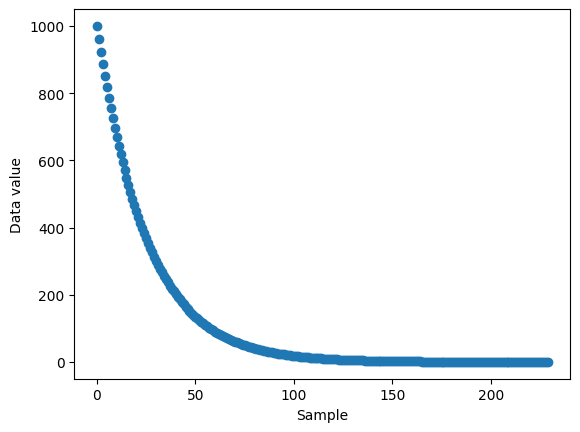

In [3]:
# generate population distribution

population = 1 / np.logspace(np.log10(.001),np.log10(10),int(population_size))

trueMean = np.mean(population)

plotskip = int(1e3)
plt.plot(population[::plotskip],'o')
plt.xlabel('Sample')
plt.ylabel('Data value')
plt.show()

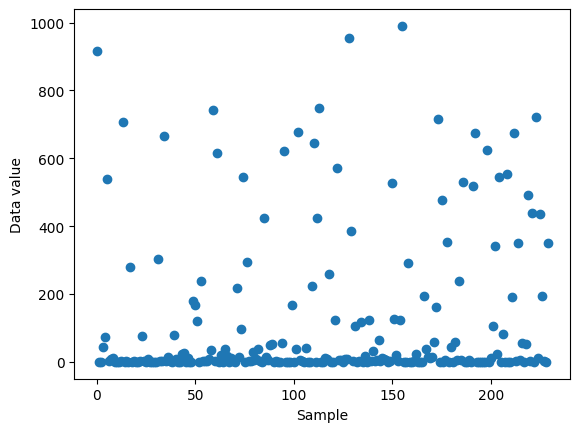

In [4]:
# shuffle the data values

np.random.shuffle(population)
plt.plot(population[::plotskip],'o')
plt.xlabel('Sample')
plt.ylabel('Data value')
plt.show()

# Monte Carlo sampling

In [5]:
# generate one random sample

randsample = np.random.choice(population,size=sample_size)
print(np.mean(randsample))

104.75492705667428


In [6]:
# Monte Carlo sampling for sample means

samplemeans = np.zeros(number_of_samples)

for expi in range(number_of_samples):
  randsample = np.random.choice(population,size=sample_size)
  samplemeans[expi] = np.mean(randsample)


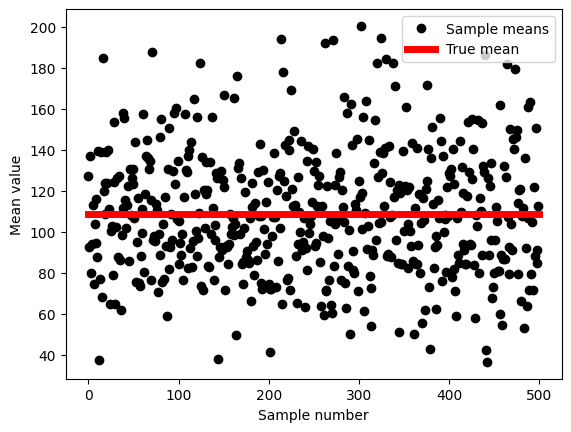

In [7]:
plt.plot(samplemeans,'ko',markerfacecolor='k',label='Sample means')
plt.plot([0,number_of_samples],[trueMean,trueMean],'r',linewidth=5,label='True mean')
plt.legend()
plt.xlabel('Sample number')
plt.ylabel('Mean value')
plt.show()

# Cumulative averaging

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


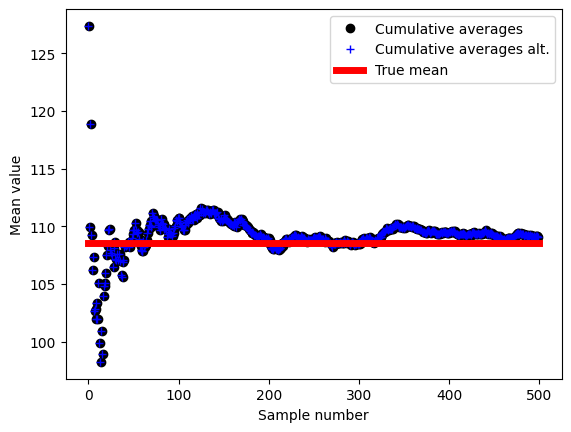

In [8]:
# Cumulative averaging

cumave = np.zeros(number_of_samples)
for i in range(number_of_samples):
  cumave[i] = np.mean(samplemeans[:i])

# alternative (loopless!)
cumave2 = np.cumsum(samplemeans) / np.arange(1,number_of_samples+1)


plt.plot(cumave,'ko',label='Cumulative averages')
plt.plot(cumave2,'b+',label='Cumulative averages alt.')
plt.plot([0,number_of_samples],[trueMean,trueMean],'r',linewidth=5,label='True mean')
plt.xlabel('Sample number')
plt.ylabel('Mean value')

plt.legend()
plt.show()

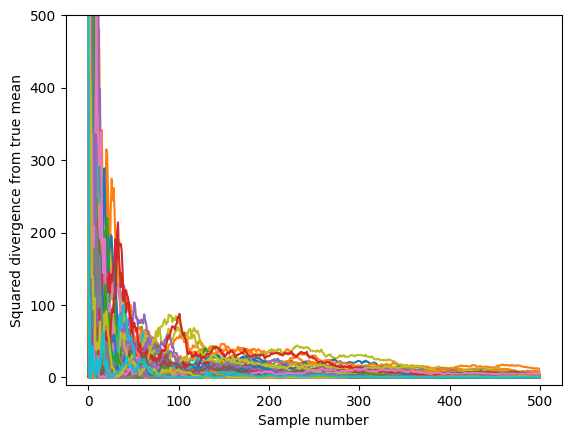

In [9]:

number_of_meta_samples = 100

cumaves = np.zeros((number_of_meta_samples,number_of_samples))
allsamplemeans = np.zeros((number_of_meta_samples,number_of_samples))

for metai in range(number_of_meta_samples):
  for expi in range(number_of_samples):
    randsample = np.random.choice(population,size=sample_size)
    samplemeans[expi] = np.mean(randsample)

  tmp = np.cumsum(samplemeans) / np.arange(1,number_of_samples+1)
  cumaves[metai,:] = (tmp-trueMean)**2
  allsamplemeans[metai,:] = samplemeans # added on later for CLT

# now plot
plt.plot(cumaves.T)
plt.ylim([-10,500])
plt.xlabel('Sample number')
plt.ylabel('Squared divergence from true mean')
plt.show()


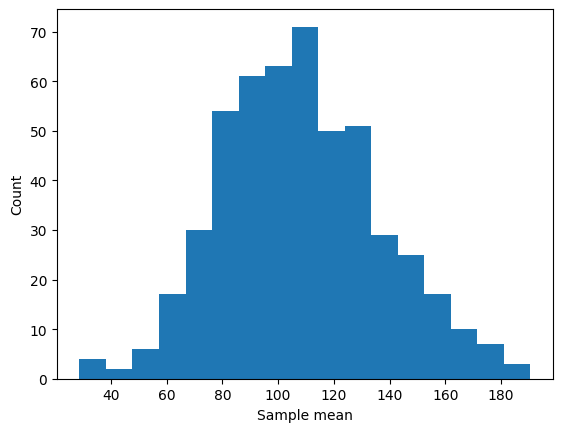

In [10]:
# Bonus: The Central Limit Theorem
plt.hist(samplemeans,bins='fd')
plt.xlabel('Sample mean')
plt.ylabel('Count')
plt.show()


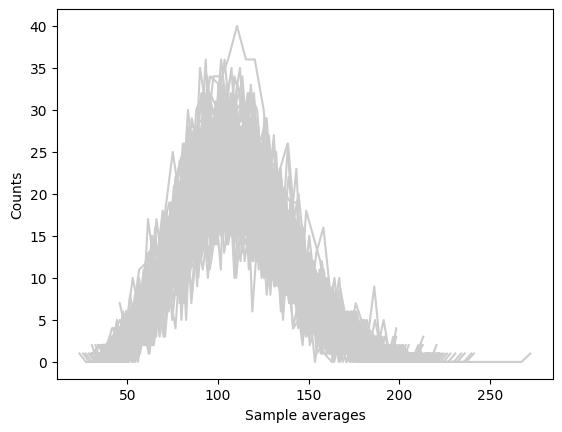

In [11]:
nbins = 50

x = np.zeros((nbins,number_of_meta_samples))
y = np.zeros((nbins,number_of_meta_samples))

for i in range(number_of_meta_samples):
  y,x = np.histogram(allsamplemeans[i,:],bins=nbins)
  x = (x[1:]+x[:-1])/2
  plt.plot(x,y,color=[.8,.8,.8])

plt.xlabel('Sample averages')
plt.ylabel('Counts')
plt.show()